In [69]:
from sklearn.datasets import make_circles

n_samples = 1000

x,y=make_circles(n_samples,noise=0.03,random_state=42)

In [71]:
x

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [72]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [73]:
import pandas as pd
circles=pd.DataFrame({'x1':x[:,0],'x2':x[:,1],
                                        "label":y})

circles.head(10)

,x1,x2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [74]:
circles.label.value_counts()

,count
label,
1,500
0,500


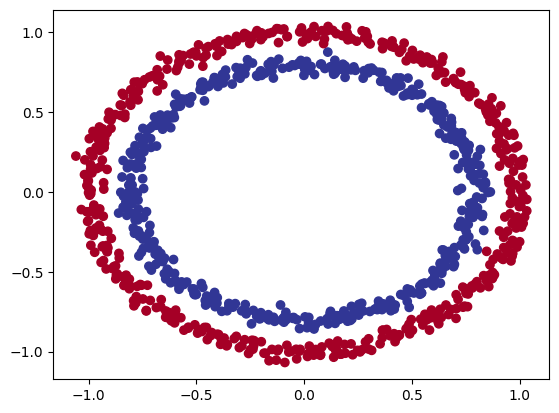

In [75]:
import matplotlib.pyplot as plt

plt.scatter(x=x[:,0],y=x[:,1],c=y,cmap=plt.cm.RdYlBu)

In [76]:
x.shape,y.shape

((1000, 2), (1000,))

In [77]:
x_sample=x[0]
y_sample=y[0]
print(x_sample)
print(y_sample)

[0.75424625 0.23148074]
1


In [78]:
import torch
x=torch.from_numpy(x).type(torch.float)
y=torch.from_numpy(y).type(torch.float)
x[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [79]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

len(x_train),len(x_test),len(y_train),len(y_test)

(800, 200, 800, 200)

In [80]:
import torch
from torch import nn
device = 'cuda' if torch.cuda.is_available()else 'cpu'
device

'cpu'

In [81]:
class circlemodelv0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1=nn.Linear(in_features=2,out_features=5)
    self.layer2=nn.Linear(in_features=10,out_features=10)
    self.layer3=nn.Linear(in_features=10,out_features=1)

  def forward (self,x):
    return self.layer3(self.layer2(self.layer_1(x)))

model_0=circlemodelv0().to(device)

model_0


circlemodelv0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
)

In [82]:
device

'cpu'

In [83]:
next(model_0.parameters()).device

device(type='cpu')

In [84]:
model_0=nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [85]:
untrained_preds = model_0(x_test.to(device))
print(untrained_preds[:10])
print(y_test[:10])

tensor([[-0.4083],
        [-0.2835],
        [-0.5719],
        [-0.3626],
        [-0.3124],
        [-0.2382],
        [-0.0925],
        [-0.0813],
        [-0.5826],
        [-0.2723]], grad_fn=<SliceBackward0>)
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [86]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.5869, -0.7030],
                      [ 0.2023, -0.1545],
                      [ 0.2753, -0.5803],
                      [ 0.5250, -0.5191],
                      [-0.1221,  0.1477]])),
             ('0.bias', tensor([ 0.3650,  0.5709,  0.6441, -0.5607,  0.1780])),
             ('1.weight',
              tensor([[-0.1924, -0.0490, -0.3347,  0.4073, -0.3282]])),
             ('1.bias', tensor([0.2390]))])

In [87]:
loss_fn=nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.1)

In [88]:
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

In [89]:
y_logits = model_0(x_test)[:5]
y_logits

tensor([[-0.4083],
        [-0.2835],
        [-0.5719],
        [-0.3626],
        [-0.3124]], grad_fn=<SliceBackward0>)

In [90]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.3993],
        [0.4296],
        [0.3608],
        [0.4103],
        [0.4225]], grad_fn=<SigmoidBackward0>)

In [91]:
y_preds = torch.round(y_pred_probs)

y_pred_labels=torch.round(torch.sigmoid(model_0(x_test)[:5]))

print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 0., 0., 0.], grad_fn=<SqueezeBackward0>)

In [92]:
y_pred_labels[:5],y_preds[:5]

(tensor([[0.],
         [0.],
         [0.],
         [0.],
         [0.]], grad_fn=<SliceBackward0>),
 tensor([[0.],
         [0.],
         [0.],
         [0.],
         [0.]], grad_fn=<SliceBackward0>))

In [93]:
torch.manual_seed(42)

epochs = 500

for epoch in range(epochs):
   model_0.train()

   y_logits = model_0(x_train).squeeze()

   y_pred=torch.round(torch.sigmoid(y_logits))

   loss = loss_fn(y_logits,y_train)

   acc = accuracy_fn(y_true=y_train,y_pred=y_pred)

   optimizer.zero_grad()

   loss.backward()

   optimizer.step()

   model_0.eval()

   with torch.inference_mode():
    test_logits=model_0(x_test).squeeze()
    test_preds=torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,y_test)
    test_acc = accuracy_fn(y_true=y_test,y_pred=test_preds)

    if epoch % 10 == 0 :
      print(f"Epoch: {epoch} | Loss: {loss:.4f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")






Epoch: 0 | Loss: 0.7123, Accuracy: 50.00% | Test Loss: 0.71473, Test Accuracy: 50.00%
Epoch: 10 | Loss: 0.6993, Accuracy: 41.38% | Test Loss: 0.70258, Test Accuracy: 41.50%
Epoch: 20 | Loss: 0.6957, Accuracy: 48.50% | Test Loss: 0.69890, Test Accuracy: 48.50%
Epoch: 30 | Loss: 0.6945, Accuracy: 48.62% | Test Loss: 0.69755, Test Accuracy: 51.00%
Epoch: 40 | Loss: 0.6940, Accuracy: 49.50% | Test Loss: 0.69694, Test Accuracy: 50.00%
Epoch: 50 | Loss: 0.6938, Accuracy: 49.50% | Test Loss: 0.69659, Test Accuracy: 49.50%
Epoch: 60 | Loss: 0.6936, Accuracy: 50.00% | Test Loss: 0.69635, Test Accuracy: 49.50%
Epoch: 70 | Loss: 0.6935, Accuracy: 50.12% | Test Loss: 0.69616, Test Accuracy: 50.00%
Epoch: 80 | Loss: 0.6934, Accuracy: 50.00% | Test Loss: 0.69601, Test Accuracy: 49.00%
Epoch: 90 | Loss: 0.6933, Accuracy: 50.25% | Test Loss: 0.69588, Test Accuracy: 48.00%
Epoch: 100 | Loss: 0.6933, Accuracy: 50.62% | Test Loss: 0.69577, Test Accuracy: 48.50%
Epoch: 110 | Loss: 0.6932, Accuracy: 50.38%

In [94]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


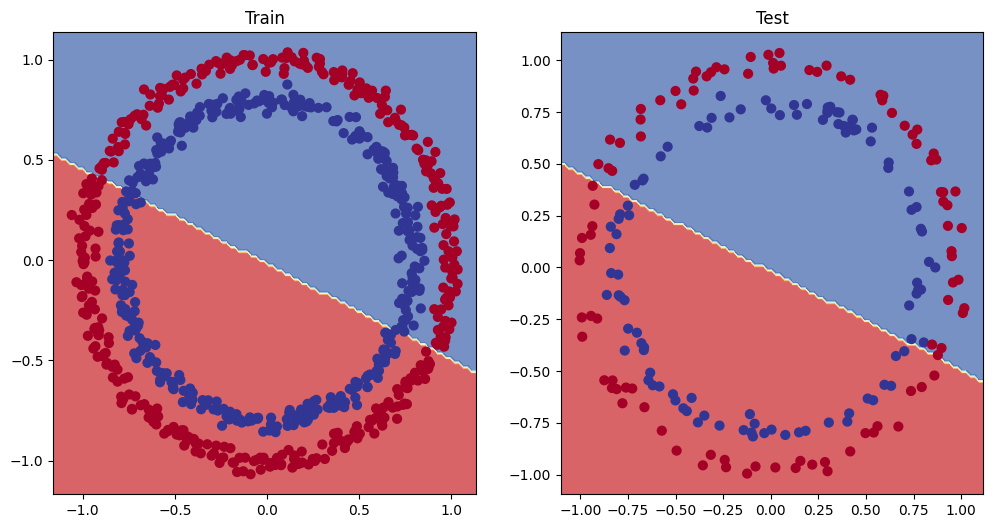

In [95]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, x_test, y_test)

In [96]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

x_reg=torch.arange(start,end,step).unsqueeze(dim=1)
y_reg=weight * x_reg + bias

x_reg

tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900],
        [0.1000],
        [0.1100],
        [0.1200],
        [0.1300],
        [0.1400],
        [0.1500],
        [0.1600],
        [0.1700],
        [0.1800],
        [0.1900],
        [0.2000],
        [0.2100],
        [0.2200],
        [0.2300],
        [0.2400],
        [0.2500],
        [0.2600],
        [0.2700],
        [0.2800],
        [0.2900],
        [0.3000],
        [0.3100],
        [0.3200],
        [0.3300],
        [0.3400],
        [0.3500],
        [0.3600],
        [0.3700],
        [0.3800],
        [0.3900],
        [0.4000],
        [0.4100],
        [0.4200],
        [0.4300],
        [0.4400],
        [0.4500],
        [0.4600],
        [0.4700],
        [0.4800],
        [0.4900],
        [0.5000],
        [0.5100],
        [0.5200],
        [0.5300],
        [0.5400],
        [0

In [97]:
train_split = int(0.8 * len(x_reg))
x_train_reg,y_train_reg=x_reg[:train_split],y_reg[:train_split]
x_test_reg,y_test_reg=x_reg[train_split:],y_reg[train_split:]

print(len(x_train_reg),
    len(y_train_reg),
    len(x_test_reg),
    len(y_test_reg))

80 80 20 20


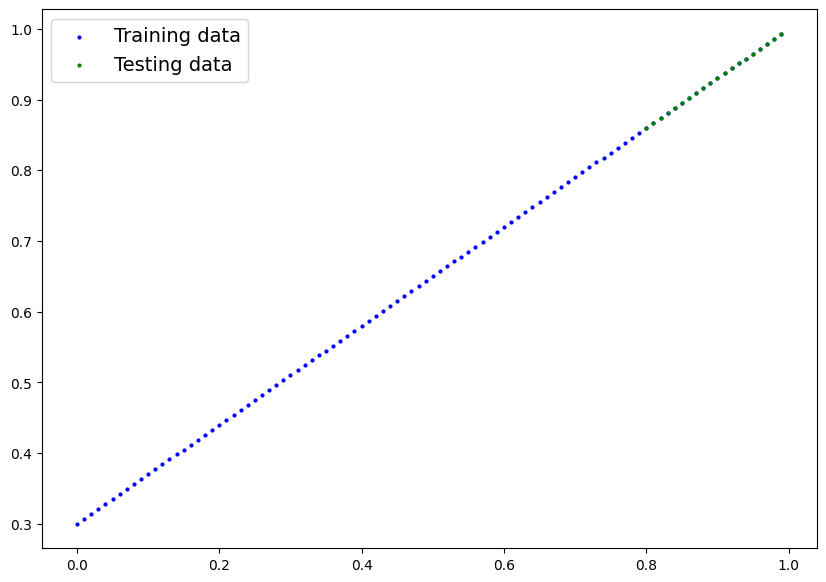

In [98]:
plot_predictions(train_data=x_reg,train_labels=y_reg,test_data=x_test_reg,test_labels=y_test_reg)

In [99]:
model2=nn.Sequential(
    nn.Linear(in_features=1,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10,out_features=1)
)

model2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [100]:
loss_fn=nn.L1Loss()
optmizer= torch.optim.SGD(model2.parameters(),lr=0.1)

In [101]:
torch.manual_seed(42)

epochs=200

for epoch in range (epochs):

  model2.train()

  y_pred=model2(x_train_reg)

  loss=loss_fn(y_pred,y_train_reg)

  optmizer.zero_grad()

  loss.backward()

  optmizer.step()

  model2.eval()

  with torch.inference_mode():
    test_pred=model2(x_test_reg)
    test_loss = loss_fn(test_pred,y_test_reg)

  if epoch % 100 == 0 :
      print(f"epoch : {epoch} |  train loss : {loss},  test loss : {test_loss}")







epoch : 0 |  train loss : 0.7598584890365601,  test loss : 0.541427731513977
epoch : 100 |  train loss : 0.09308688342571259,  test loss : 0.029011687263846397


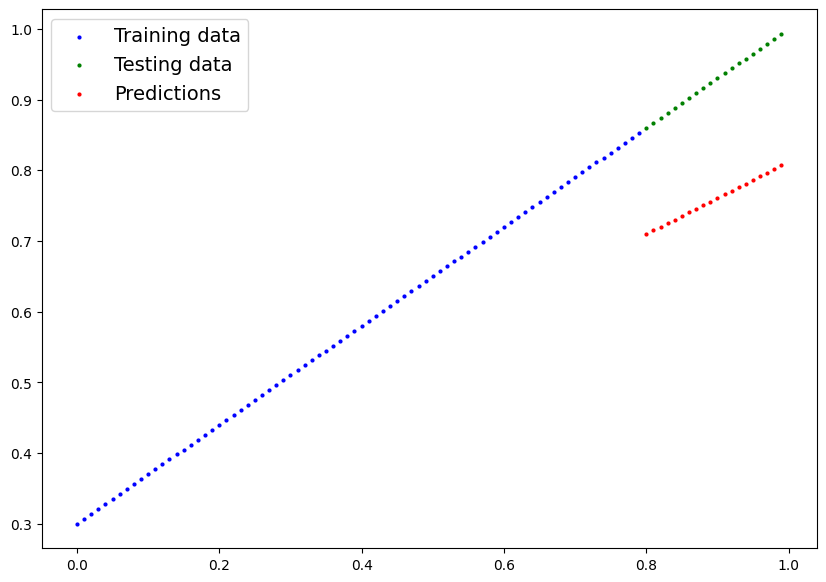

In [102]:

model2.eval()

with torch.inference_mode():
    y_preds = model2(x_test_reg)


plot_predictions(train_data=x_train_reg,
                 train_labels=y_train_reg,
                 test_data=x_test_reg,
                 test_labels=y_test_reg,
                 predictions=y_preds)

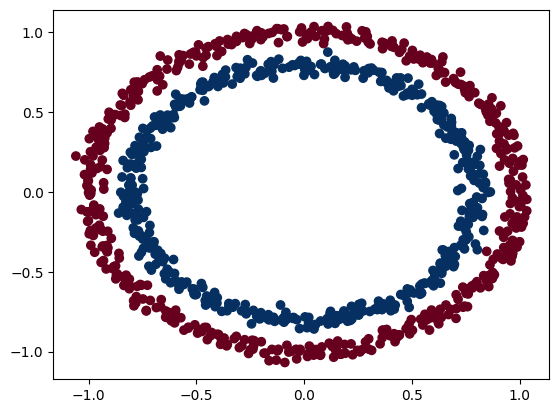

In [103]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

x,y = make_circles(n_samples,noise=0.03,random_state=42)

plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.RdBu);

In [104]:
import torch

from sklearn.model_selection import train_test_split

x = torch.from_numpy(x).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

len(x_train),len(x_test),len(y_train),len(y_test)

(800, 200, 800, 200)

In [115]:
from torch import nn

class circlemodel1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features = 2 , out_features = 10)
    self.layer_2=nn.Linear(in_features = 10 , out_features=10)
    self.layer_3=nn.Linear(in_features = 10 , out_features=1)
    self.relu=nn.ReLU()


  def forward(self,x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model3=circlemodel1()
print(model3)






circlemodel1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [116]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model3.parameters(),lr=0.1)

In [122]:
torch.manual_seed=42

epochs = 500
for epoch in range (epochs):


  y_logits=model3(x_train).squeeze()

  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits,y_train)

  acc = accuracy_fn(y_true=y_train,y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model3.eval()

  with torch.inference_mode():
    test_logits = model3(x_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,y_test)
    test_acc = accuracy_fn(y_true = y_test , y_pred=test_pred)


  if epoch % 100 ==0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")




Epoch: 0 | Loss: 0.01963, Accuracy: 99.88% | Test Loss: 0.03769, Test Accuracy: 100.00%
Epoch: 100 | Loss: 0.01834, Accuracy: 99.88% | Test Loss: 0.03591, Test Accuracy: 100.00%
Epoch: 200 | Loss: 0.01722, Accuracy: 99.88% | Test Loss: 0.03433, Test Accuracy: 100.00%
Epoch: 300 | Loss: 0.01623, Accuracy: 99.88% | Test Loss: 0.03294, Test Accuracy: 100.00%
Epoch: 400 | Loss: 0.01534, Accuracy: 100.00% | Test Loss: 0.03172, Test Accuracy: 100.00%


In [123]:

model3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model3(x_test))).squeeze()
y_preds[:10], y[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

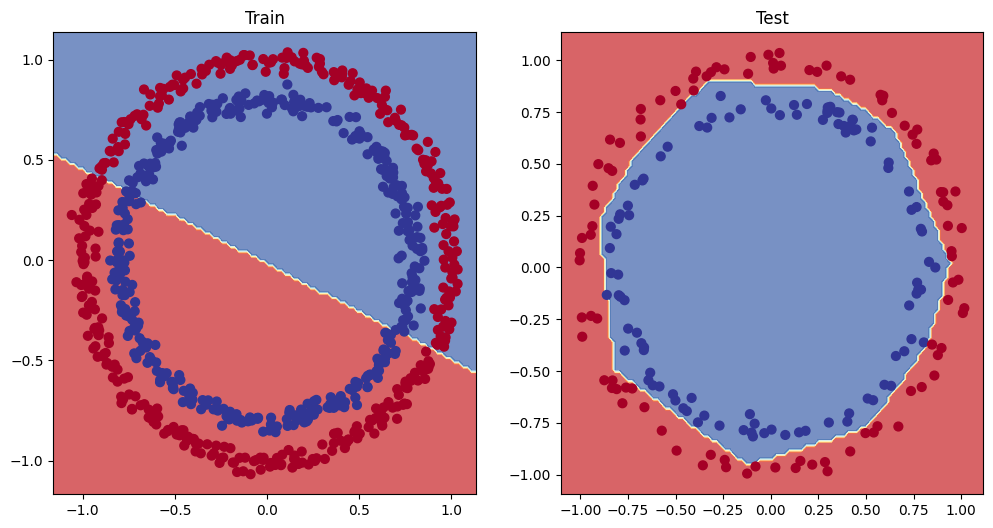

In [124]:

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model3, x_test, y_test)

In [132]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_preds,normalize=True)*100

100.0